# 05 · 模型評估：別只看準確率

「準確率 95%」聽起來很棒，但若 100 個病人裡只有 5 個生病，模型**全猜沒病**也有 95%。準確率會騙人。這一課學會用**交叉驗證**估得更穩，用**混淆矩陣、precision / recall、ROC** 看清模型真正的能力。

## 學習目標

- 用 **交叉驗證（cross-validation）** 得到更可靠的分數
- 讀懂 **混淆矩陣**
- 理解 **precision（精確率）/ recall（召回率）/ F1**
- 畫 **ROC 曲線** 並算 **AUC**

## 1. 交叉驗證：一次切分不夠看

只切一次訓練/測試，分數會受「剛好切到哪些資料」影響。**K-fold 交叉驗證**把資料切成 K 份，輪流拿其中 1 份當測試、其餘訓練，跑 K 次取平均——分數更穩、還附帶一個波動範圍。

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

data = load_breast_cancer()
X, y = data.data, data.target   # 二元分類：0=惡性, 1=良性

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
scores = cross_val_score(model, X, y, cv=5)   # 5 折

print("5 折各自的準確率:", scores.round(3))
print(f"平均 {scores.mean():.3f} ± {scores.std():.3f}")

5 折各自的準確率: [0.982 0.982 0.974 0.974 0.991]
平均 0.981 ± 0.007


## 2. 混淆矩陣：對在哪、錯在哪

準確率只給一個數字，**混淆矩陣**告訴你錯誤的型態：把真實 vs 預測的每種組合數出來。對醫療、詐欺這類問題，「把生病的誤判成健康」遠比反過來嚴重——混淆矩陣才看得到這件事。

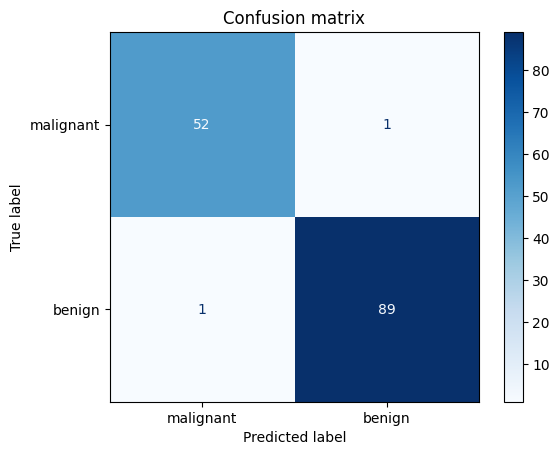

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
model.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, display_labels=data.target_names, cmap="Blues"
)
plt.title("Confusion matrix")
plt.show()

## 3. Precision / Recall / F1

從混淆矩陣可以算出三個關鍵指標（針對「陽性」類別）：

- **Precision（精確率）**：模型說陽性的，有幾成真的是陽性？（不要亂喊狼）
- **Recall（召回率）**：真正的陽性，被抓出幾成？（不要漏掉病人）
- **F1**：precision 與 recall 的調和平均，兩者的平衡。

`classification_report` 一次全給你。

In [3]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



## 4. ROC 曲線與 AUC

分類器內部其實是輸出「陽性機率」，再用 0.5 當門檻判定。**ROC 曲線**把門檻從 0 掃到 1，畫出每個門檻下的表現；曲線下面積 **AUC** 越接近 1 越好（0.5 等於亂猜）。它不受門檻選擇影響，是比較模型的好工具。

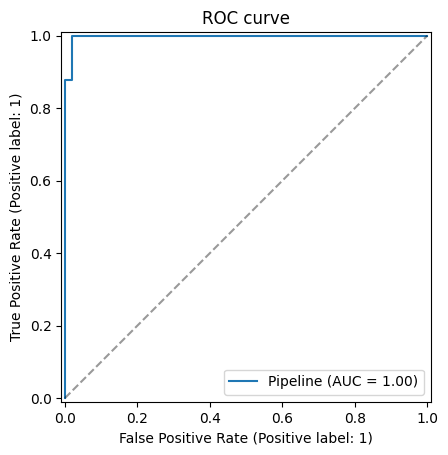

AUC: 0.998


In [4]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)   # 亂猜的對角線
plt.title("ROC curve")
plt.show()

y_proba = model.predict_proba(X_test)[:, 1]
print(f"AUC: {roc_auc_score(y_test, y_proba):.3f}")

## 小結

- **交叉驗證**比單次切分更可靠，還給你分數的波動範圍。
- **混淆矩陣**揭露錯誤的型態，不只一個總分。
- **Precision** 看「喊得準不準」、**Recall** 看「抓得全不全」、**F1** 取平衡。
- **ROC / AUC** 跨所有門檻評估，不受 0.5 預設影響。

## 練習

1. 把模型換成 `RandomForestClassifier`，比較它和邏輯迴歸的 AUC。
2. 把分類門檻從 0.5 改成 0.3（用 `y_proba >= 0.3`），recall 和 precision 怎麼變？想想醫療場景該調高還調低。

下一課進入**非監督式學習**：沒有答案，照樣能分群、降維。